In [1]:
!pip install torch pandas numpy matplotlib seaborn scikit-learn

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc

In [3]:
import pandas as pd

df = pd.read_csv("archive (1)/human_vital_signs_dataset_2024.csv")

print(df.head())
print(df.shape)

   Patient ID  Heart Rate  Respiratory Rate                   Timestamp  \
0           1          60                12  2024-07-19 21:53:45.729841   
1           2          63                18  2024-07-19 21:52:45.729841   
2           3          63                15  2024-07-19 21:51:45.729841   
3           4          99                16  2024-07-19 21:50:45.729841   
4           5          69                16  2024-07-19 21:49:45.729841   

   Body Temperature  Oxygen Saturation  Systolic Blood Pressure  \
0         36.861707          95.702046                      124   
1         36.511633          96.689413                      126   
2         37.052049          98.508265                      131   
3         36.654748          95.011801                      118   
4         36.975098          98.623792                      138   

   Diastolic Blood Pressure  Age  Gender  Weight (kg)  Height (m)  \
0                        86   37  Female    91.541618    1.679351   
1       

In [4]:
selected_features = [
'Heart Rate',
'Respiratory Rate',
'Body Temperature',
'Oxygen Saturation',
'Systolic Blood Pressure',
'Diastolic Blood Pressure',
'Age',
'Gender',
'Derived_BMI',
'Derived_HRV',
'Risk Category'
]

df_filtered = df[selected_features].copy()

print(df_filtered.head())

   Heart Rate  Respiratory Rate  Body Temperature  Oxygen Saturation  \
0          60                12         36.861707          95.702046   
1          63                18         36.511633          96.689413   
2          63                15         37.052049          98.508265   
3          99                16         36.654748          95.011801   
4          69                16         36.975098          98.623792   

   Systolic Blood Pressure  Diastolic Blood Pressure  Age  Gender  \
0                      124                        86   37  Female   
1                      126                        84   77    Male   
2                      131                        78   68  Female   
3                      118                        72   41  Female   
4                      138                        76   25  Female   

   Derived_BMI  Derived_HRV Risk Category  
0    32.459031     0.121033     High Risk  
1    12.771246     0.117062     High Risk  
2    28.821069     0

In [5]:
df_shuffled = df_filtered.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_shuffled.head())

   Heart Rate  Respiratory Rate  Body Temperature  Oxygen Saturation  \
0          95                12         37.300428          95.072205   
1          82                13         36.101797          97.354042   
2          87                12         36.280715          96.441567   
3          74                18         37.200086          95.634409   
4          82                19         36.257703          96.895731   

   Systolic Blood Pressure  Diastolic Blood Pressure  Age  Gender  \
0                      134                        78   28  Female   
1                      123                        70   39  Female   
2                      112                        78   47    Male   
3                      135                        86   82    Male   
4                      133                        74   76    Male   

   Derived_BMI  Derived_HRV Risk Category  
0    22.723303     0.149623     High Risk  
1    28.739027     0.090224      Low Risk  
2    18.704338     0

In [6]:
n = len(df_shuffled)

ward_a = df_shuffled.iloc[:n//3]
ward_b = df_shuffled.iloc[n//3:2*n//3]
ward_c = df_shuffled.iloc[2*n//3:]

print(len(ward_a), len(ward_b), len(ward_c))

66673 66673 66674


In [7]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [8]:
scaler = StandardScaler()
le_gender = LabelEncoder()

numerical_cols = [
'Heart Rate',
'Respiratory Rate',
'Body Temperature',
'Oxygen Saturation',
'Systolic Blood Pressure',
'Diastolic Blood Pressure',
'Age',
'Derived_BMI',
'Derived_HRV'
]

global_fit_df = pd.concat([ward_a, ward_b, ward_c])

scaler.fit(global_fit_df[numerical_cols])
le_gender.fit(global_fit_df['Gender'])

LabelEncoder()

In [9]:
def preprocess_node_data(df):

    df = df.copy()

    df[numerical_cols] = scaler.transform(df[numerical_cols])
    df['Gender'] = le_gender.transform(df['Gender'])

    df['Risk Category'] = df['Risk Category'].map({
        'Low Risk':0,
        'High Risk':1
    })

    X = df.drop(columns=['Risk Category']).values
    y = df['Risk Category'].values

    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

In [10]:
X_a, y_a = preprocess_node_data(ward_a)
X_b, y_b = preprocess_node_data(ward_b)
X_c, y_c = preprocess_node_data(ward_c)

print(X_a.shape)
print(X_b.shape)
print(X_c.shape)

torch.Size([66673, 10])
torch.Size([66673, 10])
torch.Size([66674, 10])


In [11]:
class PatientRiskClassifier(nn.Module):

    def __init__(self,input_dim=10):

        super(PatientRiskClassifier,self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim,32),
            nn.ReLU(),
            nn.Linear(32,16),
            nn.ReLU(),
            nn.Linear(16,2)
        )

    def forward(self,x):
        return self.network(x)

In [12]:
global_model = PatientRiskClassifier(input_dim=10)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(global_model.parameters(), lr=0.01)

In [14]:
X_train = torch.cat([X_a, X_b, X_c], dim=0)
y_train = torch.cat([y_a, y_b, y_c], dim=0)

dataset = torch.utils.data.TensorDataset(X_train, y_train)

loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

epochs = 5

for epoch in range(epochs):

    for X_batch, y_batch in loader:

        optimizer.zero_grad()

        outputs = global_model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

    print("Epoch:", epoch+1, "Loss:", loss.item())

Epoch: 1 Loss: 0.0007567427819594741
Epoch: 2 Loss: 0.015279864892363548
Epoch: 3 Loss: 0.023044470697641373
Epoch: 4 Loss: 0.05365374684333801
Epoch: 5 Loss: 0.0008768937550485134


In [15]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

global_model.eval()

with torch.no_grad():

    outputs = global_model(X_train)

    probabilities = torch.softmax(outputs, dim=1)[:,1].numpy()

y_pred = (probabilities >= 0.3).astype(int)

y_true = y_train.numpy()

accuracy = accuracy_score(y_true,y_pred)
precision = precision_score(y_true,y_pred)
recall = recall_score(y_true,y_pred)
f1 = f1_score(y_true,y_pred)

print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1 Score:",f1)

Accuracy: 0.9931106889311069
Precision: 0.989016376441306
Recall: 0.9979736479094325
F1 Score: 0.9934748226648105


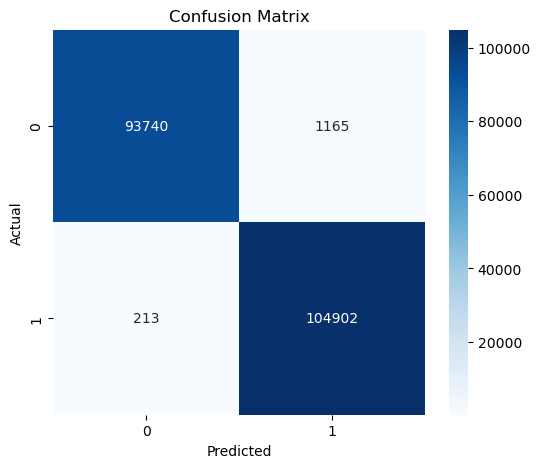

In [16]:
cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Model Evaluation Metrics")
print("------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Model Evaluation Metrics
------------------------
Accuracy : 0.9931106889311069
Precision: 0.989016376441306
Recall   : 0.9979736479094325
F1 Score : 0.9934748226648105


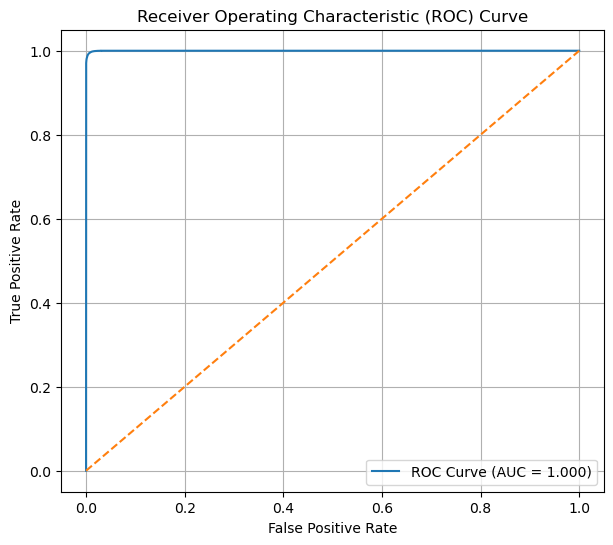

In [18]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, probabilities)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.3f)" % roc_auc)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Receiver Operating Characteristic (ROC) Curve")

plt.legend()

plt.grid()

plt.show()

In [19]:
threshold = 0.25   # tuned threshold (lower → fewer false negatives)

y_pred_tuned = (probabilities >= threshold).astype(int)

from sklearn.metrics import confusion_matrix

cm_tuned = confusion_matrix(y_true, y_pred_tuned)

print("Confusion Matrix After Hyperparameter Tuning:")
print(cm_tuned)

accuracy = accuracy_score(y_true,y_pred_tuned)
precision = precision_score(y_true,y_pred_tuned)
recall = recall_score(y_true,y_pred_tuned)
f1 = f1_score(y_true,y_pred_tuned)

print("\nAfter Hyperparameter Tuning")
print("---------------------------")
print("Accuracy :",accuracy)
print("Precision:",precision)
print("Recall   :",recall)
print("F1 Score :",f1)

Confusion Matrix After Hyperparameter Tuning:
[[ 93590   1315]
 [   162 104953]]

After Hyperparameter Tuning
---------------------------
Accuracy : 0.9926157384261574
Precision: 0.9876256257763391
Recall   : 0.9984588308043572
F1 Score : 0.9930126831391359


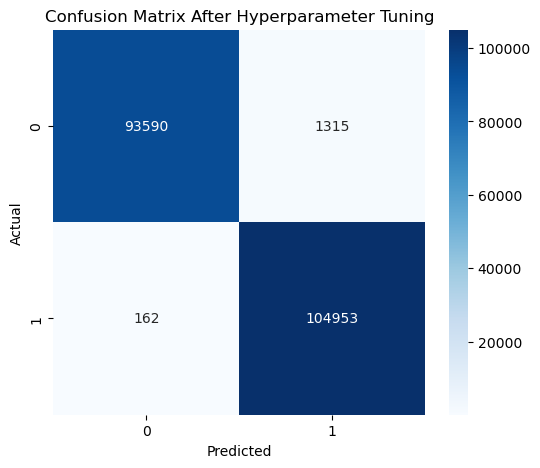

In [20]:
plt.figure(figsize=(6,5))

sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix After Hyperparameter Tuning")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()